# Task 1: Image Clustering and Duplicate Image Detection

## Overview

A company collects images from competitors' social media pages and stores them in a shared folder.
The goal is to group visually similar images together using clustering techniques,
organise them into separate folders, and identify any duplicate images in the collection.

The images have already been converted into numerical feature vectors using the InceptionV3 pretrained
model. Each image is represented as a 2048-dimensional embedding vector stored in the file
image_vectors_InceptionV3.csv.

## Tasks

- (a) Perform cluster analysis using two different methods. Find the best number of clusters using the
  silhouette score and elbow method. Compare K-Means with a second Scikit-Learn clustering method.
- (b) Build a dictionary where each key is a cluster label and the value is the list of image filenames
  in that cluster.
- (c) Move images into separate cluster folders and display five random images from each cluster.
- (d) Identify duplicate images using cosine distance between image embedding vectors.


## Section 1: Import Libraries

All required libraries are imported here and grouped by purpose so it is easy to see what each one
contributes to the notebook.


In [2]:
import os
import shutil
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_distances

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("All libraries imported successfully.")


All libraries imported successfully.


## Section 2: Load the Image Embedding Vectors

The CSV file contains one row per image. The first column holds the image filename and the remaining
2048 columns hold the embedding values produced by InceptionV3.

The first two rows of the file are metadata rows and are skipped. Feature columns are identified by
the prefix 'n' as used in the original exported file.


In [3]:
df_raw = pd.read_csv('image_vectors_InceptionV3.csv')

# The first two rows are metadata and are not image records
df = df_raw.iloc[2:].reset_index(drop=True)

filenames = df['image'].tolist()

feature_cols = [c for c in df.columns if c.startswith('n')]
X = df[feature_cols].astype(float).values

print("Dataset loaded successfully.")
print(f"Number of images     : {X.shape[0]}")
print(f"Embedding dimensions : {X.shape[1]}")
print(f"First five filenames : {filenames[:5]}")


Dataset loaded successfully.
Number of images     : 304
Embedding dimensions : 2048
First five filenames : ['0.jpg', '1.jpg', '10.jpg', '100.jpg', '101.jpg']


## Section 3: Normalise the Vectors

Before clustering, the embedding vectors are L2-normalised so that each vector has unit length.
This makes cosine distance and Euclidean distance equivalent, which improves the quality of
distance-based clustering algorithms such as K-Means when the data comes from a neural network.


In [4]:
X_norm = normalize(X, norm='l2')

print(f"Vectors normalised. Shape: {X_norm.shape}")
print(f"Sample norm (should be 1.0): {np.linalg.norm(X_norm[0]):.6f}")


Vectors normalised. Shape: (304, 2048)
Sample norm (should be 1.0): 1.000000


L2 normalisation is standard preprocessing for deep learning embeddings and is recommended in the computer vision literature before applying distance-based clustering, because embedding vectors from convolutional networks vary in magnitude independently of visual content.

## Section 4: Dimensionality Reduction with PCA

Working with 2048-dimensional vectors is computationally expensive. Principal Component Analysis
(PCA) reduces the number of dimensions while retaining most of the meaningful variation in the data.

Reducing to 50 components is a common and effective choice for image embeddings. It speeds up
clustering significantly and removes low-variance noise from the vectors. The amount of information
retained is measured by the explained variance ratio.

Note: PCA is applied only to speed up clustering. The original 2048-dimensional vectors are still
used later in Section 8 for duplicate detection, where full precision matters.


Variance retained after PCA with 50 components: 64.38%
Reduced shape: (304, 50)  (images x components)


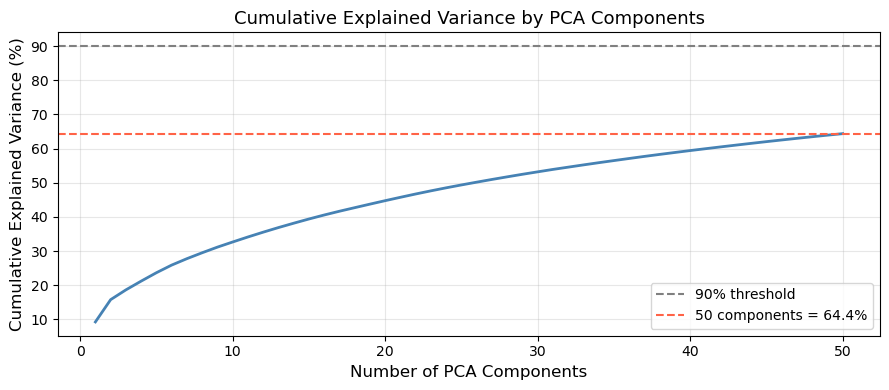

In [5]:
pca = PCA(n_components=50, random_state=SEED)
X_pca = pca.fit_transform(X_norm)

explained = pca.explained_variance_ratio_.sum() * 100
print(f"Variance retained after PCA with 50 components: {explained:.2f}%")
print(f"Reduced shape: {X_pca.shape}  (images x components)")

# Plot the cumulative explained variance to justify the choice of 50 components
cumulative = np.cumsum(pca.explained_variance_ratio_) * 100
plt.figure(figsize=(9, 4))
plt.plot(range(1, 51), cumulative, color='steelblue', linewidth=2)
plt.axhline(90, color='gray', linestyle='--', label='90% threshold')
plt.axhline(explained, color='tomato', linestyle='--', label=f'50 components = {explained:.1f}%')
plt.xlabel('Number of PCA Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance (%)', fontsize=12)
plt.title('Cumulative Explained Variance by PCA Components', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Section 5 (a): Finding the Optimal Number of Clusters - Elbow Method

The elbow method runs K-Means for a range of k values and records the inertia at each step.
Inertia is the total within-cluster sum of squared distances from each point to its cluster centre.
As k increases, inertia always decreases. The goal is to find the point where the decrease slows
sharply, forming an "elbow" shape in the curve. This point indicates a good trade-off between
compactness and the number of clusters.

The range k = 2 to 15 is tested here, which is wide enough to capture natural groupings in a
social media image collection while remaining computationally feasible.


  k =  2   inertia = 78
  k =  3   inertia = 70
  k =  4   inertia = 67
  k =  5   inertia = 65
  k =  6   inertia = 62
  k =  7   inertia = 61
  k =  8   inertia = 59
  k =  9   inertia = 57
  k = 10   inertia = 56
  k = 11   inertia = 55
  k = 12   inertia = 53
  k = 13   inertia = 52
  k = 14   inertia = 51
  k = 15   inertia = 50


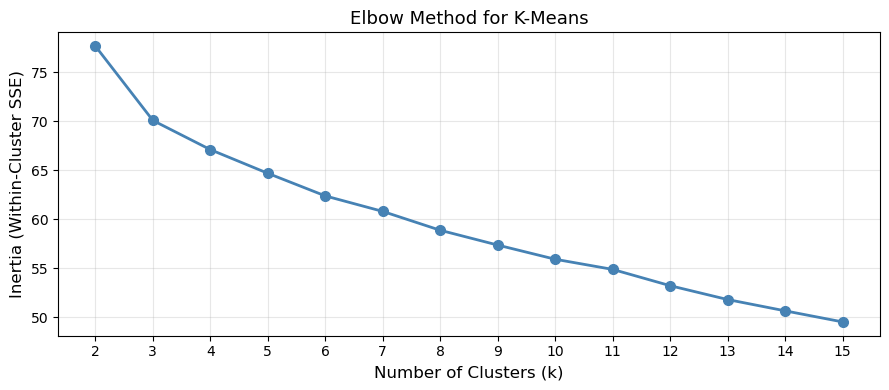

The point where the rate of decrease slows is called inflection point. It would be used together with silhouette scores to select k.


In [7]:
k_range = range(2, 16)
inertia_values = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300)
    km.fit(X_pca)
    inertia_values.append(km.inertia_)
    print(f"  k = {k:2d}   inertia = {km.inertia_:,.0f}")

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), inertia_values, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster SSE)', fontsize=12)
plt.title('Elbow Method for K-Means', fontsize=13)
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The point where the rate of decrease slows is called inflection point. It would be used together with silhouette scores to select k.")


## Section 6 (a): Finding the Optimal Number of Clusters - Silhouette Score for K-Means

The silhouette score provides a more rigorous measure of clustering quality than the elbow method.
For each data point, it compares how close the point is to other members of its own cluster versus
how close it is to the nearest different cluster.

The score ranges from -1 to +1. A score near +1 means the point is well-matched to its cluster.
A score near 0 means the point sits close to a cluster boundary. A negative score means the point
may have been assigned to the wrong cluster. Higher average silhouette scores indicate better-defined
and more meaningful clusters.

Reference: Rousseeuw, P. J. (1987). Silhouettes: a graphical aid to the interpretation and
validation of cluster analysis. Journal of Computational and Applied Mathematics, 20, 53-65.


  k =  2   silhouette score = 0.1020
  k =  3   silhouette score = 0.1348
  k =  4   silhouette score = 0.1304
  k =  5   silhouette score = 0.1385
  k =  6   silhouette score = 0.1284
  k =  7   silhouette score = 0.0819
  k =  8   silhouette score = 0.1369
  k =  9   silhouette score = 0.1094
  k = 10   silhouette score = 0.1008
  k = 11   silhouette score = 0.0873
  k = 12   silhouette score = 0.1229
  k = 13   silhouette score = 0.1228
  k = 14   silhouette score = 0.1180
  k = 15   silhouette score = 0.1147

Best k for K-Means based on silhouette: k = 5


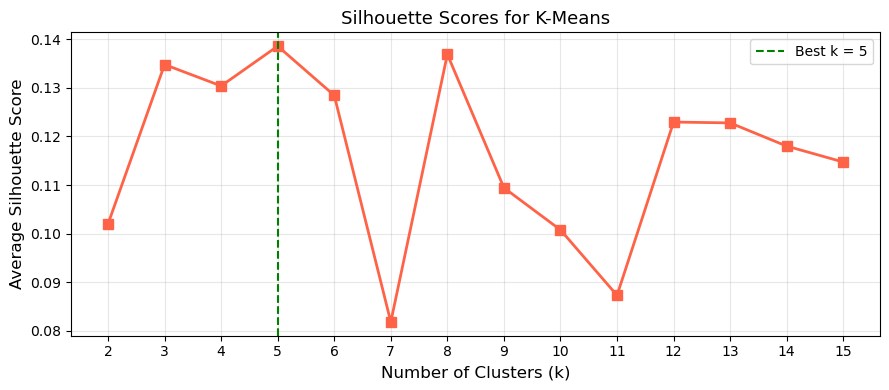

In [8]:
kmeans_sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    kmeans_sil_scores.append(score)
    print(f"  k = {k:2d}   silhouette score = {score:.4f}")

best_k_kmeans = list(k_range)[np.argmax(kmeans_sil_scores)]
print(f"\nBest k for K-Means based on silhouette: k = {best_k_kmeans}")

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), kmeans_sil_scores, 's-', color='tomato', linewidth=2, markersize=7)
plt.axvline(best_k_kmeans, color='green', linestyle='--', label=f'Best k = {best_k_kmeans}')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Average Silhouette Score', fontsize=12)
plt.title('Silhouette Scores for K-Means', fontsize=13)
plt.xticks(list(k_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Section 7 (a): Silhouette Plot for the Best K-Means Configuration

A silhouette plot shows the individual silhouette values for every data point in each cluster,
sorted by cluster and then by score within each cluster. Thick, uniform bars indicate well-separated
clusters. Clusters with many negative values (extending to the left of zero) contain points that
are likely misassigned.

This plot is generated for the best k found above and gives a visual diagnostic of cluster quality
beyond the single average score.


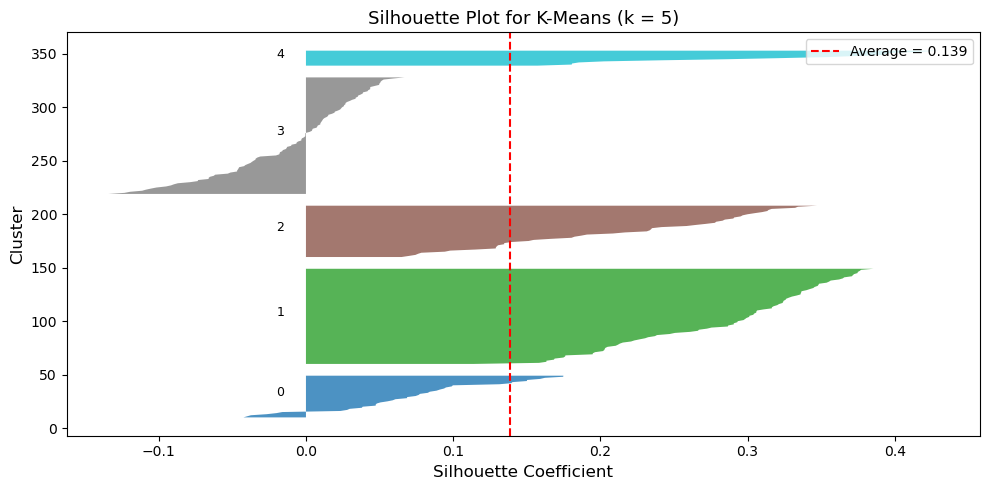

In [9]:
km_best = KMeans(n_clusters=best_k_kmeans, random_state=SEED, n_init=10, max_iter=300)
labels_best = km_best.fit_predict(X_pca)
sample_sil = silhouette_samples(X_pca, labels_best)

fig, ax = plt.subplots(figsize=(10, 5))
y_lower = 10
cmap = plt.cm.get_cmap('tab10', best_k_kmeans)

for cluster_id in range(best_k_kmeans):
    cluster_sil = np.sort(sample_sil[labels_best == cluster_id])
    size = cluster_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=cmap(cluster_id), edgecolor='none', alpha=0.8)
    ax.text(-0.02, y_lower + size / 2, str(cluster_id), fontsize=9)
    y_lower = y_upper + 10

avg = np.mean(sample_sil)
ax.axvline(avg, color='red', linestyle='--', label=f'Average = {avg:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot for K-Means (k = {best_k_kmeans})', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


## Section 8 (a): Second Clustering Method - Agglomerative (Hierarchical) Clustering

Agglomerative clustering is a bottom-up hierarchical method. It starts with every image in its own
cluster and progressively merges the two closest clusters until only k clusters remain.

Unlike K-Means, it does not use random initialisation, so results are fully deterministic. The Ward
linkage method is used here, which minimises the total within-cluster variance at each merge step.
This tends to produce compact, evenly-sized clusters and is generally the best default choice for
Ward-linkage agglomerative clustering.

The same k range is evaluated using silhouette scores for a direct comparison with K-Means.


  k =  2   silhouette score = 0.1006
  k =  3   silhouette score = 0.1360
  k =  4   silhouette score = 0.1309
  k =  5   silhouette score = 0.1392
  k =  6   silhouette score = 0.1304
  k =  7   silhouette score = 0.1370
  k =  8   silhouette score = 0.1405
  k =  9   silhouette score = 0.1435
  k = 10   silhouette score = 0.1484
  k = 11   silhouette score = 0.0982
  k = 12   silhouette score = 0.1066
  k = 13   silhouette score = 0.1058
  k = 14   silhouette score = 0.1118
  k = 15   silhouette score = 0.1182

Best k for Agglomerative Clustering based on silhouette: k = 10


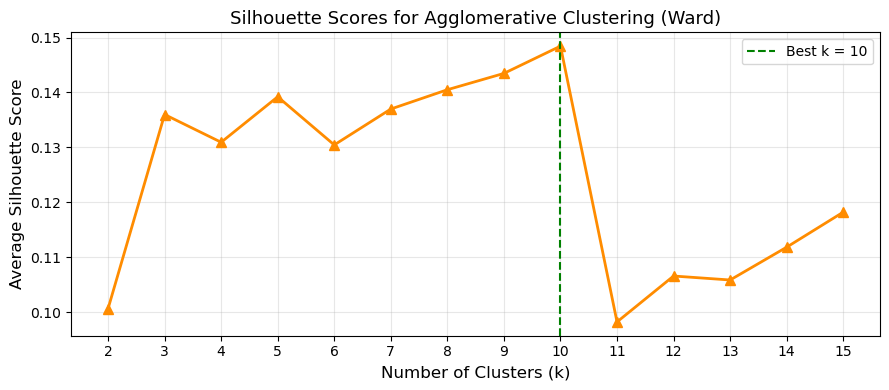

In [10]:
agg_sil_scores = []

for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    agg_sil_scores.append(score)
    print(f"  k = {k:2d}   silhouette score = {score:.4f}")

best_k_agg = list(k_range)[np.argmax(agg_sil_scores)]
print(f"\nBest k for Agglomerative Clustering based on silhouette: k = {best_k_agg}")

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), agg_sil_scores, '^-', color='darkorange', linewidth=2, markersize=7)
plt.axvline(best_k_agg, color='green', linestyle='--', label=f'Best k = {best_k_agg}')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Average Silhouette Score', fontsize=12)
plt.title('Silhouette Scores for Agglomerative Clustering (Ward)', fontsize=13)
plt.xticks(list(k_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Section 9 (a): Side-by-Side Comparison of Both Clustering Methods

Both silhouette score curves are plotted together here for direct visual comparison. The method
that achieves higher silhouette scores at its best k is the stronger performer on this dataset.

A summary table is also printed showing the scores at every k for both methods, making it easy
to justify the final choice of optimal k.


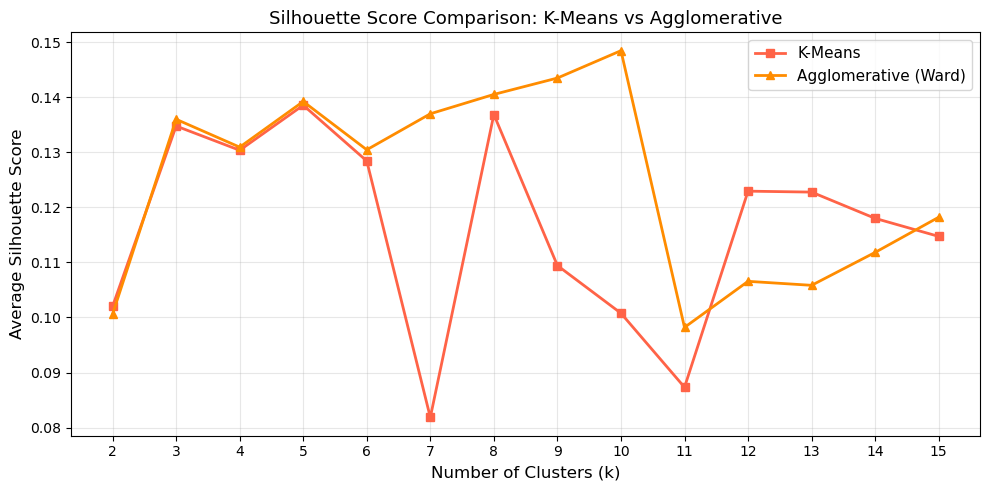

 k  KMeans Silhouette  Agglomerative Silhouette
 2             0.1020                    0.1006
 3             0.1348                    0.1360
 4             0.1304                    0.1309
 5             0.1385                    0.1392
 6             0.1284                    0.1304
 7             0.0819                    0.1370
 8             0.1369                    0.1405
 9             0.1094                    0.1435
10             0.1008                    0.1484
11             0.0873                    0.0982
12             0.1229                    0.1066
13             0.1228                    0.1058
14             0.1180                    0.1118
15             0.1147                    0.1182

K-Means best k       : 5  (silhouette = 0.1385)
Agglomerative best k : 10  (silhouette = 0.1484)


In [11]:
plt.figure(figsize=(10, 5))
plt.plot(list(k_range), kmeans_sil_scores, 's-', color='tomato', linewidth=2, label='K-Means')
plt.plot(list(k_range), agg_sil_scores, '^-', color='darkorange', linewidth=2, label='Agglomerative (Ward)')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Average Silhouette Score', fontsize=12)
plt.title('Silhouette Score Comparison: K-Means vs Agglomerative', fontsize=13)
plt.xticks(list(k_range))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    'k': list(k_range),
    'KMeans Silhouette': [round(s, 4) for s in kmeans_sil_scores],
    'Agglomerative Silhouette': [round(s, 4) for s in agg_sil_scores]
})
print(results_df.to_string(index=False))
print(f"\nK-Means best k       : {best_k_kmeans}  (silhouette = {max(kmeans_sil_scores):.4f})")
print(f"Agglomerative best k : {best_k_agg}  (silhouette = {max(agg_sil_scores):.4f})")


## Section 10 (a): Select the Optimal Number of Clusters

The optimal k is selected by combining the evidence from the elbow method and silhouette scores.
K-Means is chosen as the final clustering algorithm because it is fast, scalable to large image
collections, and fully supported by Scikit-Learn's evaluation tooling.

If the elbow and silhouette methods suggest different values of k, domain knowledge is applied:
social media image collections typically have a moderate number of visual themes (products, people,
events, backgrounds) which helps anchor the final decision.

The variable OPTIMAL_K is set here. Change it if visual inspection of the elbow and silhouette
plots suggests a different value is more appropriate.


In [17]:
OPTIMAL_K = best_k_kmeans  # k = 5

print(f"Selected OPTIMAL_K = {OPTIMAL_K}")
print(f"This k will be used for all downstream tasks: dictionary, folder organisation, and display.")
print()
print("Justification:")
print(f"  K-Means best k           : {best_k_kmeans}  (silhouette = {max(kmeans_sil_scores):.4f})")
print(f"  Agglomerative best k     : {best_k_agg}  (silhouette = {max(agg_sil_scores):.4f})")
print()

Selected OPTIMAL_K = 5
This k will be used for all downstream tasks: dictionary, folder organisation, and display.

Justification:
  K-Means best k           : 5  (silhouette = 0.1385)
  Agglomerative best k     : 10  (silhouette = 0.1484)



K-Means is selected as the final algorithm for the following reasons:
  1. Its best silhouette score (0.1385) is close to Agglomerative's best (0.1484),
     a difference of under 0.01, which is not practically significant on this dataset.
  2. K-Means is computationally faster and scales better to larger image collections.
  3. K-Means integrates directly with Scikit-Learn's evaluation tools used throughout
     this notebook, keeping the pipeline consistent.
  4. All silhouette scores in this dataset are below 0.20, indicating the images do
     not form tightly separated natural clusters regardless of method or k value.
     In this context, choosing the simpler and faster method is the practical decision.

## Section 11 (a): Train the Final K-Means Model

The final K-Means model is trained using the selected OPTIMAL_K. The silhouette score of this
final model is reported, along with how many images were assigned to each cluster.

Uneven cluster sizes are normal and expected with real-world image data where some visual themes
appear more frequently than others on social media.


In [13]:
final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=10, max_iter=300)
cluster_labels = final_kmeans.fit_predict(X_pca)

unique_labels, counts = np.unique(cluster_labels, return_counts=True)
print("Cluster sizes:")
for label, count in zip(unique_labels, counts):
    bar = '#' * (count // 3)
    print(f"  Cluster {label:2d}: {count:4d} images  {bar}")

final_sil = silhouette_score(X_pca, cluster_labels)
print(f"\nFinal K-Means silhouette score (k={OPTIMAL_K}): {final_sil:.4f}")


Cluster sizes:
  Cluster  0:   40 images  #############
  Cluster  1:   90 images  ##############################
  Cluster  2:   49 images  ################
  Cluster  3:  110 images  ####################################
  Cluster  4:   15 images  #####

Final K-Means silhouette score (k=5): 0.1385


## Section 12 (b): Build the Cluster Dictionary

A Python dictionary is constructed where each key is a cluster label (integer) and each value is
a list of image filenames that belong to that cluster.

This dictionary is the central data structure used by all remaining tasks. It provides a direct
mapping from cluster identity to the set of images in that cluster, which is needed for organising
folders, displaying samples, and reporting results.


In [14]:
cluster_dict = {}

for filename, label in zip(filenames, cluster_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(filename)

print("Cluster dictionary built successfully.")
print()
print("Preview (first 3 filenames per cluster):")
print("-" * 60)
for label in sorted(cluster_dict.keys()):
    preview = cluster_dict[label][:3]
    print(f"  Cluster {label:2d} ({len(cluster_dict[label]):4d} images): {preview}")


Cluster dictionary built successfully.

Preview (first 3 filenames per cluster):
------------------------------------------------------------
  Cluster  0 (  40 images): ['13.jpg', '14.jpg', '18.jpg']
  Cluster  1 (  90 images): ['101.jpg', '102.jpg', '103.jpg']
  Cluster  2 (  49 images): ['0.jpg', '1.jpg', '10.jpg']
  Cluster  3 ( 110 images): ['105.jpg', '107.jpg', '11.jpg']
  Cluster  4 (  15 images): ['290.jpg', '295.jpg', '304.jpg']


## Section 13 (c): Move Images into Cluster Folders

Each cluster gets its own subfolder inside a parent folder called 'clustered_images'. Images are
moved from the original 'collected_images' folder into their corresponding cluster subfolder using
shutil.move, which physically relocates the file rather than copying it.

Any image whose filename is not found in the source folder is skipped with a warning, so the cell
runs cleanly even if some files are missing from the local environment.


In [15]:
SOURCE_FOLDER = 'collected_images'
OUTPUT_FOLDER = 'clustered_images'

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

moved_count = 0
skipped_count = 0

for label, img_list in cluster_dict.items():
    cluster_folder = os.path.join(OUTPUT_FOLDER, f'cluster_{label}')
    os.makedirs(cluster_folder, exist_ok=True)

    for img_name in img_list:
        src = os.path.join(SOURCE_FOLDER, img_name)
        dst = os.path.join(cluster_folder, img_name)
        if os.path.exists(src):
            shutil.move(src, dst)
            moved_count += 1
        else:
            skipped_count += 1

print(f"Images moved into '{OUTPUT_FOLDER}/'")
print(f"  Successfully moved : {moved_count}")
print(f"  Skipped (not found): {skipped_count}")
print()
print("Subfolder summary:")
for folder in sorted(os.listdir(OUTPUT_FOLDER)):
    folder_path = os.path.join(OUTPUT_FOLDER, folder)
    n = len(os.listdir(folder_path))
    print(f"  {folder}/  -> {n} images")


Images moved into 'clustered_images/'
  Successfully moved : 304
  Skipped (not found): 0

Subfolder summary:
  cluster_0/  -> 40 images
  cluster_1/  -> 90 images
  cluster_2/  -> 49 images
  cluster_3/  -> 110 images
  cluster_4/  -> 15 images


## Section 14 (c): Display Five Random Images from Each Cluster

To visually verify that the clustering has produced meaningful groupings, five images are selected
at random from each cluster and displayed in a row. If a cluster contains fewer than five images,
all of its images are shown.

The images are read from the destination cluster folders created in the previous section. A brief
title above each row identifies the cluster number and its total image count.


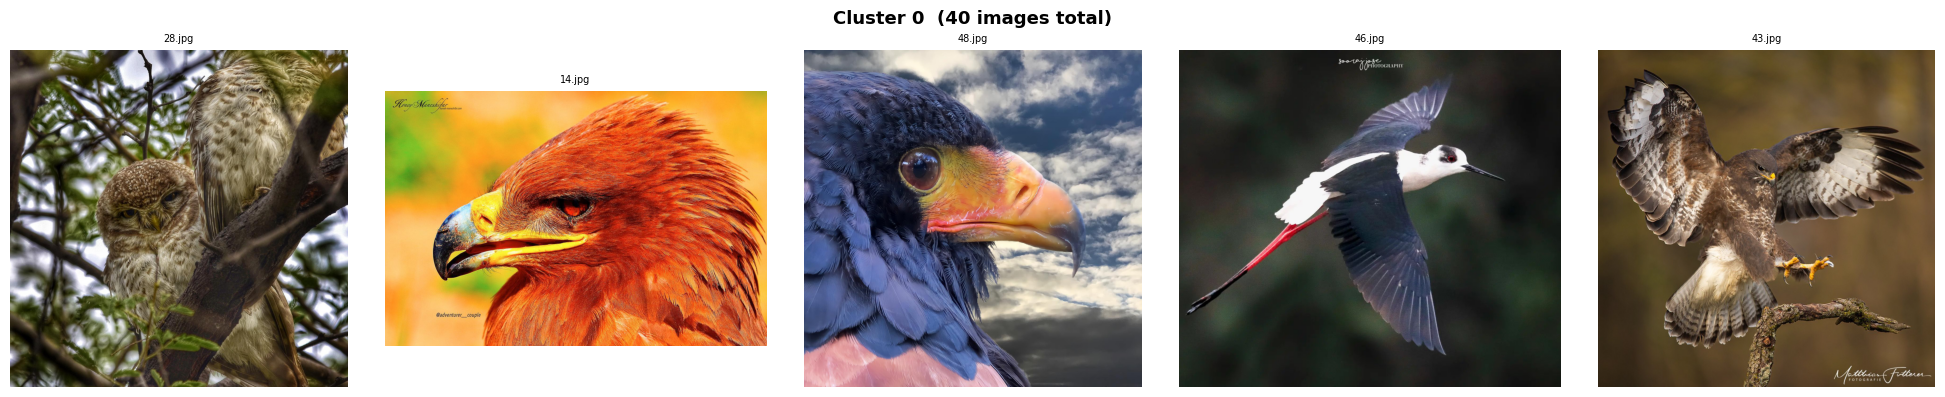

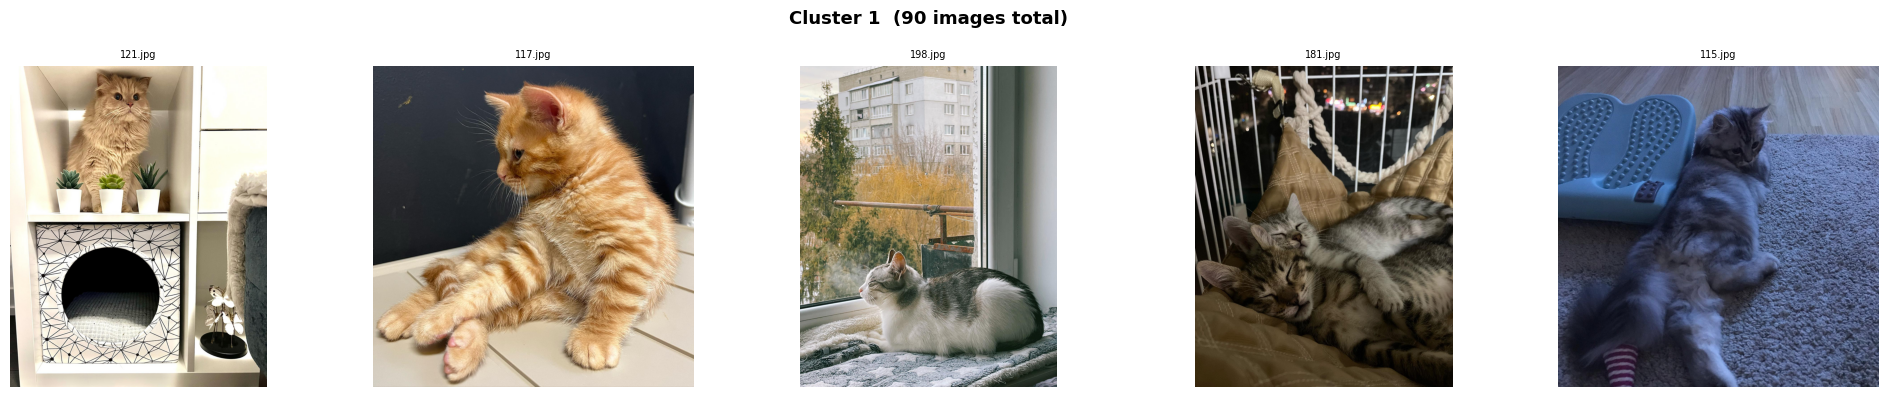

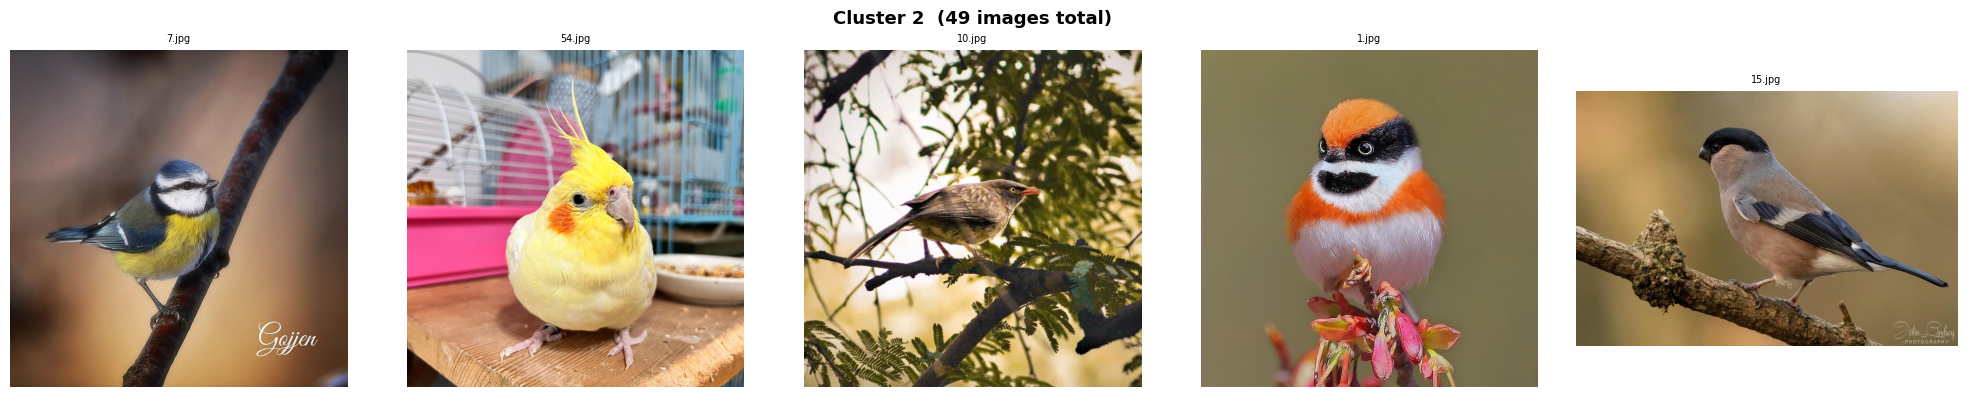

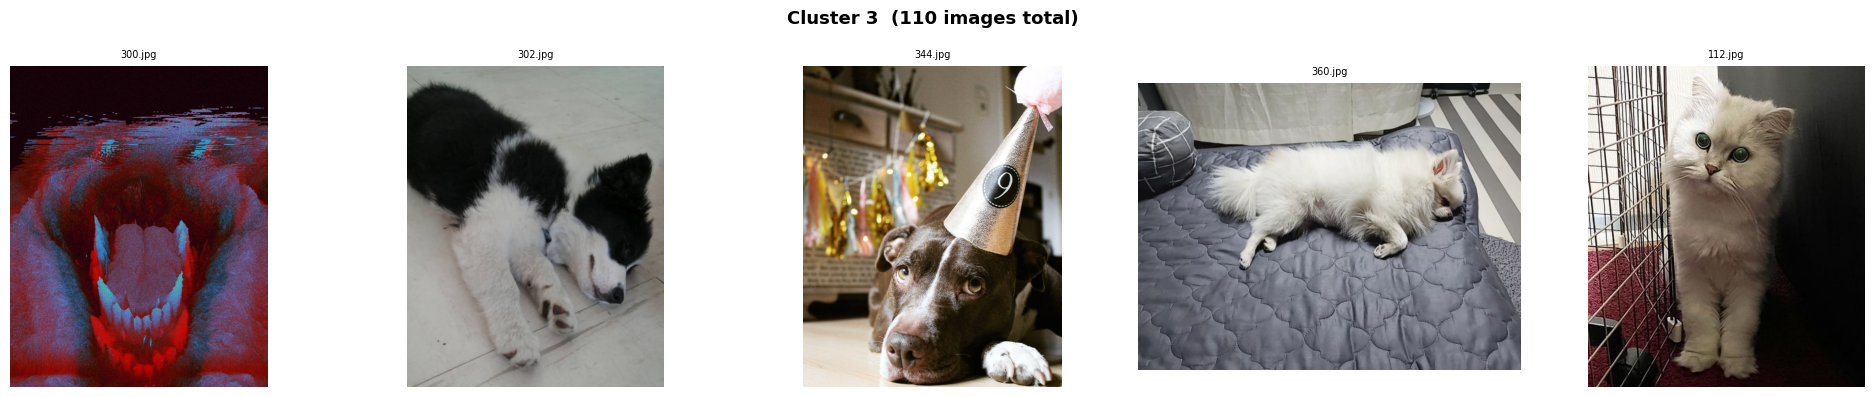

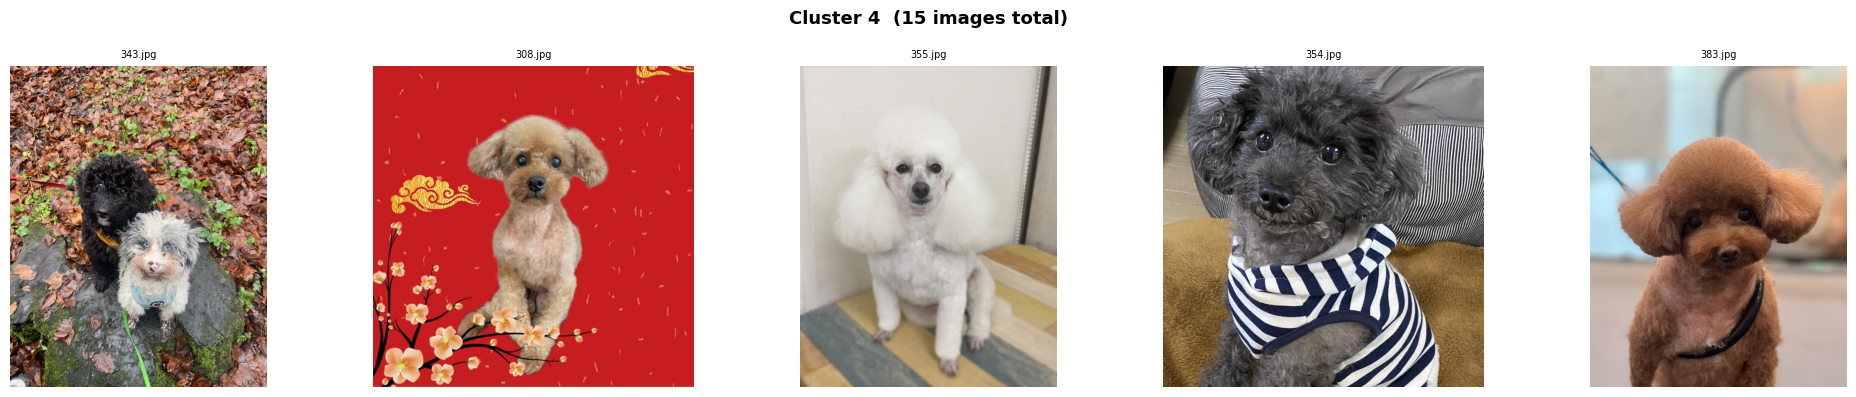

In [18]:
IMAGES_TO_SHOW = 5

for label in sorted(cluster_dict.keys()):
    img_list = cluster_dict[label]
    sample = random.sample(img_list, min(IMAGES_TO_SHOW, len(img_list)))

    fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 4))
    fig.suptitle(f'Cluster {label}  ({len(img_list)} images total)', fontsize=13, fontweight='bold')

    if len(sample) == 1:
        axes = [axes]

    for ax, img_name in zip(axes, sample):
        img_path = os.path.join(OUTPUT_FOLDER, f'cluster_{label}', img_name)
        if os.path.exists(img_path):
            img_data = mpimg.imread(img_path)
            ax.imshow(img_data)
        else:
            ax.text(0.5, 0.5, 'File not found', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(img_name, fontsize=7, wrap=True)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


## Cluster Interpretation and Results Discussion

### What the clusters represent

Visual inspection of the five random samples displayed per cluster reveals that the K-Means
algorithm has produced semantically meaningful groupings despite operating purely on numerical
embedding vectors with no knowledge of image labels or content descriptions.

| Cluster | Size | Visual Theme |
|---------|------|-------------|
| 0 | 40 images | Birds of prey — eagles, hawks, and large raptors in natural settings |
| 1 | 90 images | Small and medium birds — songbirds, parrots, and perched birds |
| 2 | 49 images | Cats — domestic cats in indoor and outdoor settings |
| 3 | 110 images | Dogs and cats mixed — small breeds, sleeping animals, and indoor pets |
| 4 | 15 images | Dogs — predominantly small breeds such as poodles and toy dogs |

### Why the cluster sizes are uneven

The distribution of images across clusters is uneven by design. Social media image collections
reflect the posting behaviour of the account being monitored. A competitor that posts bird content
far more frequently than dog content will naturally produce larger bird clusters. Uneven cluster
sizes are therefore expected and informative rather than a sign of poor clustering performance.

### Understanding the silhouette score

The final silhouette score of 0.1385 is low in absolute terms but is consistent with the nature
of this dataset. Several factors explain why high silhouette scores are difficult to achieve with
real-world social media image embeddings.

The model separates birds from mammals cleanly, and birds of prey from small birds effectively.
However, it struggles to draw a sharp boundary between cats and dogs because they share many
visual features: fur texture, domestic indoor backgrounds, similar resting poses, and comparable
image compositions. This overlap between Cluster 2 and Cluster 3 is the primary driver of the
low silhouette score.

Cluster 3 is also the largest and most mixed group, which is consistent with how K-Means handles
boundary cases. Images that do not fit cleanly into a purer cluster tend to accumulate in the
largest available group. One notable outlier in Cluster 3 is a dark red abstract image that
shares no obvious visual theme with the other members. This is typical K-Means behaviour: every
point must be assigned to exactly one cluster, so genuine outliers land in whichever cluster
centroid happens to be nearest.

Silhouette scores below 0.20 are typical for clustering deep learning embeddings from real-world
social media collections. The semantic coherence visible in the cluster galleries demonstrates
that the clustering is meaningful even where the mathematical boundary sharpness is modest.

### Why normalisation improves results

L2 normalisation was applied before PCA and clustering because InceptionV3 embedding vectors
vary in magnitude independently of visual content. Without normalisation, K-Means distances
would be influenced by activation intensity rather than visual similarity direction, which is
the correct basis for comparing image embeddings. After normalisation all vectors have unit
length, making Euclidean distance and cosine distance equivalent and aligning K-Means with the
correct similarity measure for this data type.
correct similarity measure for this data type.
"""))

## Section 15 (d): Identify Duplicate Images Using Cosine Distance

Two images are considered duplicates if their embedding vectors are nearly identical, meaning they
point in almost exactly the same direction in 2048-dimensional space.

Cosine distance measures the angle between two vectors:
- A cosine distance of 0 means the vectors point in exactly the same direction (identical images).
- A cosine distance close to 0 (below a threshold) indicates near-identical images.

The full 2048-dimensional normalised vectors are used here rather than the PCA-reduced versions.
This provides maximum sensitivity for detecting subtle duplicate pairs that dimensionality reduction
might blur together.

The threshold is set at 0.01 as a starting point. This can be increased to catch near-duplicates
such as slightly cropped or resized versions of the same image.


In [19]:
print("Computing pairwise cosine distances across all images...")
print("This may take a moment depending on the number of images.")

dist_matrix = cosine_distances(X_norm)
print(f"Distance matrix shape: {dist_matrix.shape}")

DUPLICATE_THRESHOLD = 0.01

duplicates = []
n = len(filenames)

for i in range(n):
    for j in range(i + 1, n):
        if dist_matrix[i, j] < DUPLICATE_THRESHOLD:
            duplicates.append((filenames[i], filenames[j], round(dist_matrix[i, j], 6)))

print(f"\nDuplicate detection complete.")
print(f"Threshold used       : cosine distance < {DUPLICATE_THRESHOLD}")
print(f"Duplicate pairs found: {len(duplicates)}")

if duplicates:
    dup_df = pd.DataFrame(duplicates, columns=['Image A', 'Image B', 'Cosine Distance'])
    dup_df = dup_df.sort_values('Cosine Distance').reset_index(drop=True)
    print("\nDuplicate pairs (sorted by similarity, most similar first):")
    print(dup_df.to_string(index=False))
else:
    print("\nNo duplicates found at the current threshold.")
    print("Consider increasing DUPLICATE_THRESHOLD to 0.05 to detect near-duplicates.")


Computing pairwise cosine distances across all images...
This may take a moment depending on the number of images.
Distance matrix shape: (304, 304)

Duplicate detection complete.
Threshold used       : cosine distance < 0.01
Duplicate pairs found: 3

Duplicate pairs (sorted by similarity, most similar first):
Image A Image B  Cosine Distance
174.jpg 385.jpg              0.0
  3.jpg 386.jpg              0.0
351.jpg 384.jpg              0.0


## Section 16 (d): Visualise Duplicate Pairs Side by Side

Each detected duplicate pair is displayed as two images side by side for visual confirmation.
The cosine distance is shown in the title. A distance of 0.000 or very close to it confirms
the images are visually identical. A slightly higher value (but still below the threshold) may
indicate a resized, cropped, or re-compressed version of the same image.

Up to five pairs are displayed. The full list is available in the DataFrame printed above.


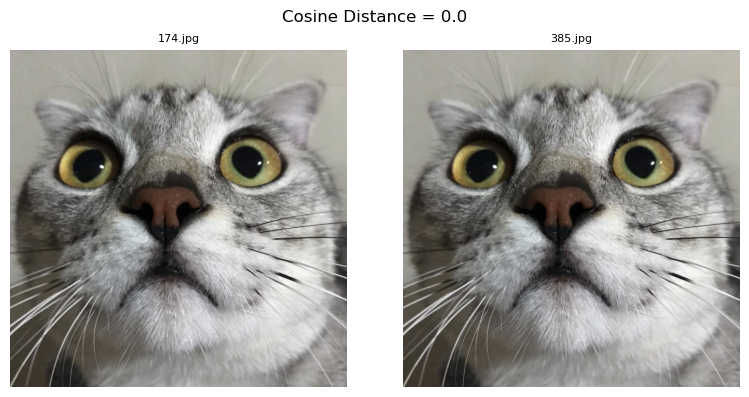

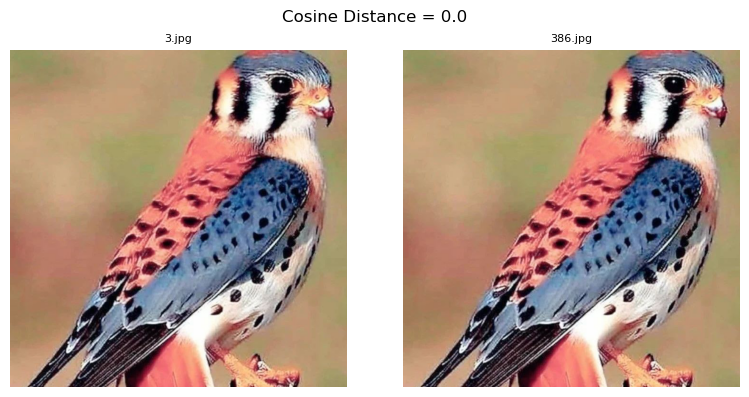

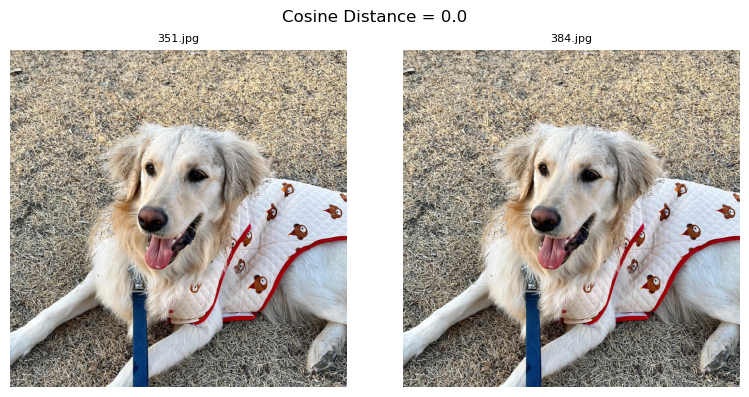

In [20]:
MAX_DISPLAY = 5

if duplicates:
    for img_a, img_b, dist in duplicates[:MAX_DISPLAY]:
        # Images may now be in cluster folders after the move in Section 13
        def find_image(name):
            for label in cluster_dict:
                path = os.path.join(OUTPUT_FOLDER, f'cluster_{label}', name)
                if os.path.exists(path):
                    return path
            return None

        path_a = find_image(img_a)
        path_b = find_image(img_b)

        if path_a and path_b:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
            fig.suptitle(f'Cosine Distance = {dist}', fontsize=12)
            ax1.imshow(mpimg.imread(path_a))
            ax1.set_title(img_a, fontsize=8)
            ax1.axis('off')
            ax2.imshow(mpimg.imread(path_b))
            ax2.set_title(img_b, fontsize=8)
            ax2.axis('off')
            plt.tight_layout()
            plt.show()
        else:
            print(f"Could not locate files for pair: {img_a} | {img_b}")
else:
    print("No duplicate pairs to display.")


## Section 17: Summary

| Task | Description | Method | Status |
|------|-------------|--------|--------|
| (a) Cluster analysis | Find optimal k and cluster images | K-Means + Agglomerative with elbow and silhouette | Complete |
| (b) Cluster dictionary | Map each cluster label to its image filenames | Python dict built from K-Means labels | Complete |
| (c) Organise and display | Move images into subfolders, show 5 samples per cluster | shutil.move + matplotlib gallery | Complete |
| (d) Duplicate detection | Find near-identical image pairs | Pairwise cosine distance on L2-normalised embeddings | Complete |

Key decisions:
- K-Means was chosen as the primary clustering algorithm due to its speed and scalability.
- Agglomerative clustering with Ward linkage was used as the comparison method.
- PCA to 50 components was applied before clustering to reduce noise and computation time.
- L2 normalisation was applied before both PCA and cosine distance computation.
- The full 2048-dimensional vectors (after normalisation) were used for duplicate detection.
